In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Home.csv to Home.csv


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier


In [ ]:
# Load the Dataset
df = pd.read_csv("Home.csv")

print(df.info())
df.head()


/tmp/ipykernel_2490/497426805.py:2: DtypeWarning: Columns (0,27) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Home.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503911 entries, 0 to 503910
Data columns (total 32 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   time                 503911 non-null  object 
 1   use [kW]             503910 non-null  float64
 2   gen [kW]             503910 non-null  float64
 3   House overall [kW]   503910 non-null  float64
 4   Dishwasher [kW]      503910 non-null  float64
 5   Furnace 1 [kW]       503910 non-null  float64
 6   Furnace 2 [kW]       503910 non-null  float64
 7   Home office [kW]     503910 non-null  float64
 8   Fridge [kW]          503910 non-null  float64
 9   Wine cellar [kW]     503910 non-null  float64
 10  Garage door [kW]     503910 non-null  float64
 11  Kitchen 12 [kW]      503910 non-null  float64
 12  Kitchen 14 [kW]      503910 non-null  float64
 13  Kitchen 38 [kW]      503910 non-null  float64
 14  Barn [kW]            503910 non-null  float64
 15  Well [kW]        

,time,use [kW],gen [kW],House overall [kW],Dishwasher [kW],Furnace 1 [kW],Furnace 2 [kW],Home office [kW],Fridge [kW],Wine cellar [kW],...,visibility,summary,apparentTemperature,pressure,windSpeed,cloudCover,windBearing,precipIntensity,dewPoint,precipProbability
0,1451624400,0.932833,0.003483,0.932833,0.000033,0.020700,0.061917,0.442633,0.124150,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
1,1451624401,0.934333,0.003467,0.934333,0.000000,0.020717,0.063817,0.444067,0.124000,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
2,1451624402,0.931817,0.003467,0.931817,0.000017,0.020700,0.062317,0.446067,0.123533,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
3,1451624403,1.022050,0.003483,1.022050,0.000017,0.106900,0.068517,0.446583,0.123133,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
4,1451624404,1.139400,0.003467,1.139400,0.000133,0.236933,0.063983,0.446533,0.122850,0.006850,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0


In [ ]:
#Select relevant features
df_iot = df[['temperature', 'humidity', 'pressure', 'House overall [kW]']].copy()
df_iot = df_iot.dropna()

print("Cleaned shape:", df_iot.shape)
df_iot.head()


Cleaned shape: (503910, 4)


,temperature,humidity,pressure,House overall [kW]
0,36.14,0.62,1016.91,0.932833
1,36.14,0.62,1016.91,0.934333
2,36.14,0.62,1016.91,0.931817
3,36.14,0.62,1016.91,1.022050
4,36.14,0.62,1016.91,1.139400


In [ ]:
# Create Labels
def classify_home(row):
    if row['temperature'] > 70:
        return "Overheating"
    elif row['House overall [kW]'] > 3:
        return "High Energy"
    else:
        return "Normal"

df_iot['label'] = df_iot.apply(classify_home, axis=1)
df_iot['label'].value_counts()


,count
label,
Normal,399682
Overheating,94877
High Energy,9351


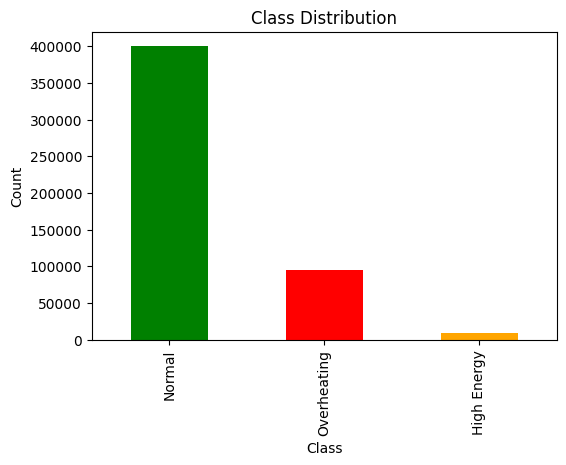

In [ ]:
#Class distribtion plots
plt.figure(figsize=(6,4))
df_iot['label'].value_counts().plot(kind='bar', color=['green','red','orange'])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


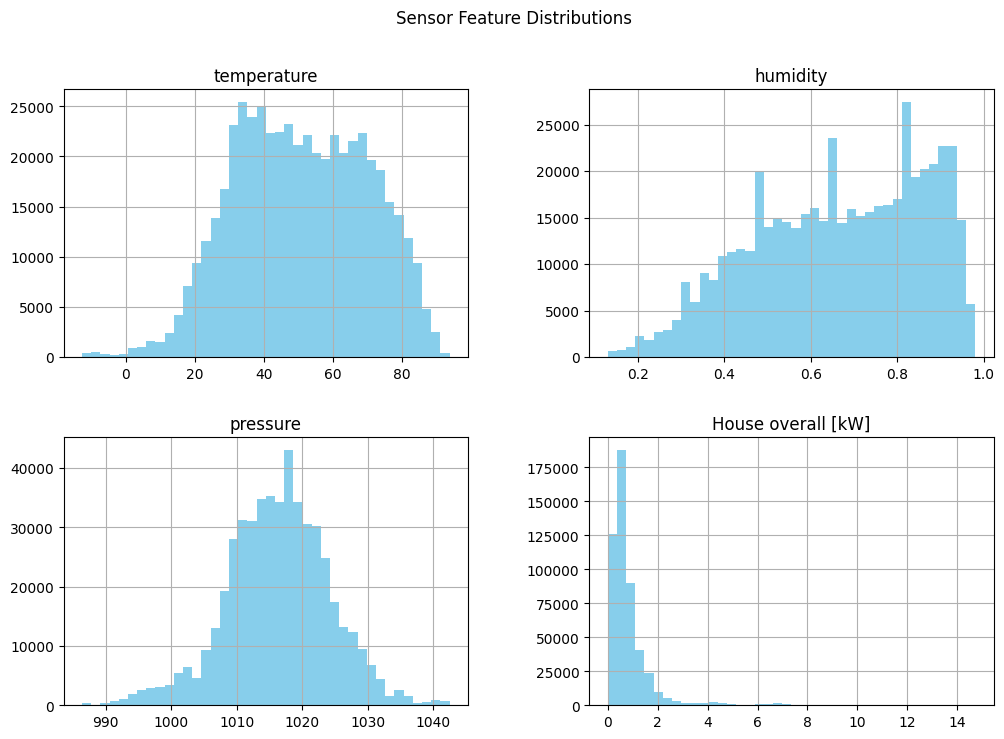

In [ ]:
#Feature Distribution
df_iot[['temperature','humidity','pressure','House overall [kW]']].hist(
    figsize=(12,8), bins=40, color='skyblue'
)
plt.suptitle("Sensor Feature Distributions")
plt.show()


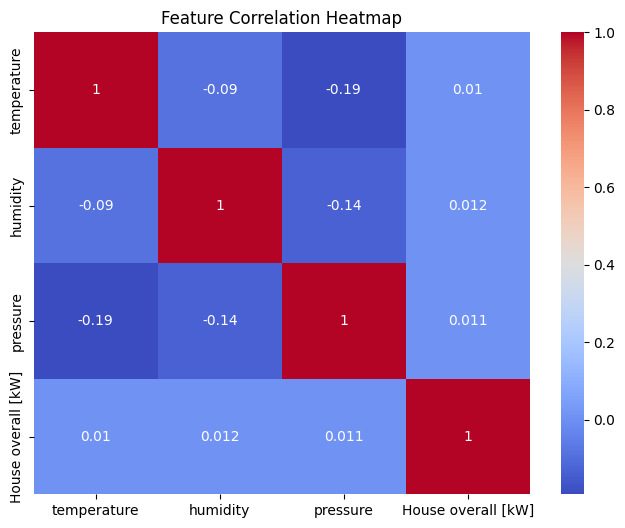

In [ ]:
#Corelation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df_iot.drop(columns=['label']).corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()



/tmp/ipykernel_2490/3114908436.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


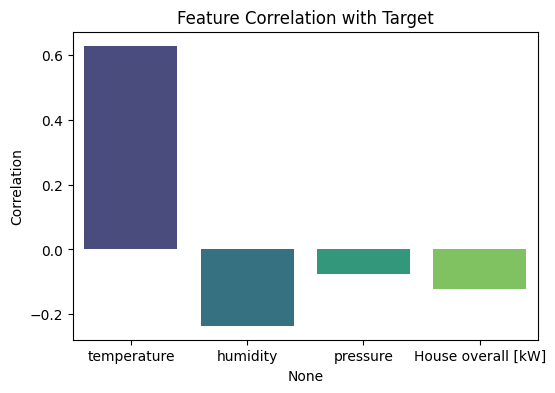

In [ ]:
#Feature correlation with target
df_corr = df_iot.copy()
df_corr['label'] = LabelEncoder().fit_transform(df_corr['label'])

plt.figure(figsize=(6,4))
sns.barplot(
    x=df_corr.corr()['label'].index[:-1],
    y=df_corr.corr()['label'][:-1],
    palette='viridis'
)
plt.title("Feature Correlation with Target")
plt.ylabel("Correlation")
plt.show()


In [ ]:
#Train/Test Split
X = df_iot[['temperature', 'humidity', 'pressure', 'House overall [kW]']]
y = df_iot['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
#Train models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, average='weighted'),
        "Recall": recall_score(y_test, preds, average='weighted'),
        "F1 Score": f1_score(y_test, preds, average='weighted')
    })

pd.DataFrame(results)


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.994721,0.994716,0.994721,0.994706
1,KNN,0.998571,0.998559,0.998571,0.998559
2,Naive Bayes,0.948999,0.953568,0.948999,0.948238


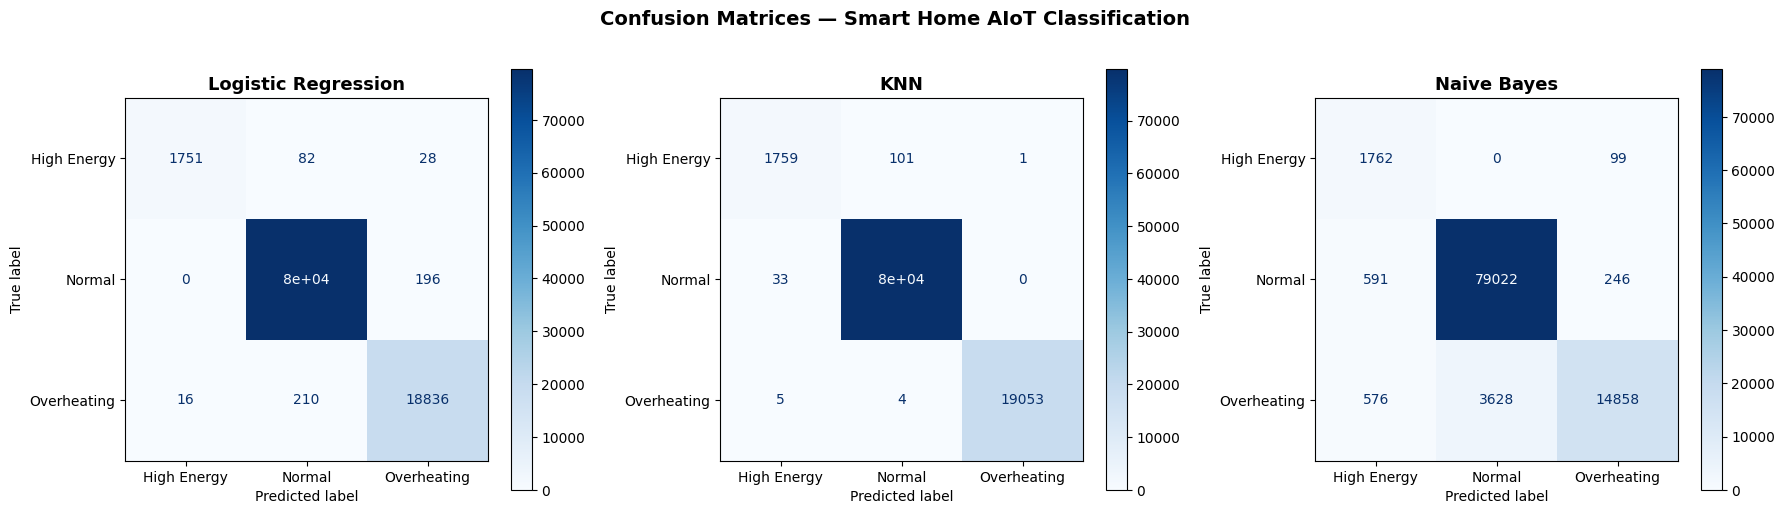

Done!


In [ ]:
# Confusion matrix for all 3 models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

lr_model = LogisticRegression(max_iter=500)
knn_model = KNeighborsClassifier()
nb_model = GaussianNB()

lr_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)
nb_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
knn_pred = knn_model.predict(X_test)
nb_pred = nb_model.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_results = [
    ('Logistic Regression', lr_pred),
    ('KNN', knn_pred),
    ('Naive Bayes', nb_pred)
]

classes = ['High Energy', 'Normal', 'Overheating']

for ax, (name, pred) in zip(axes, model_results):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=ax, colorbar=True, cmap='Blues')
    ax.set_title(name, fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices — Smart Home AIoT Classification',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

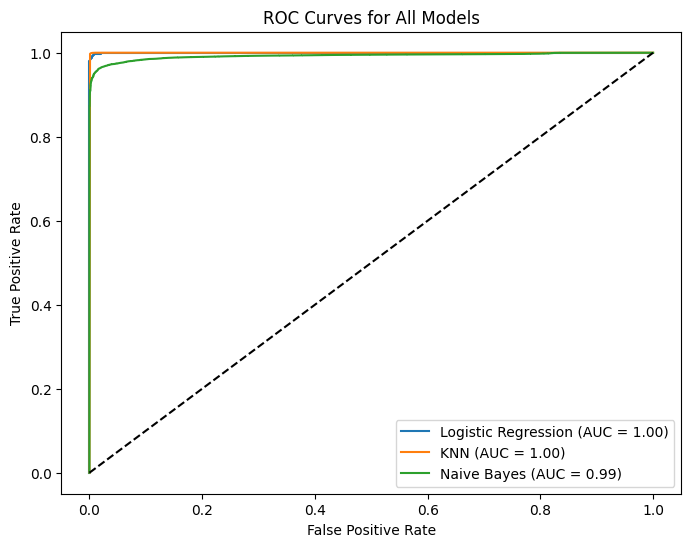

In [ ]:
# ROC Curve
plt.figure(figsize=(8,6))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)

    le = LabelEncoder()
    y_test_enc = le.fit_transform(y_test)

    fpr, tpr, _ = roc_curve(y_test_enc, y_prob[:, 1], pos_label=1)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curves for All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


Feature Importance Values:
[('temperature', np.float64(0.8760905349621906)), ('humidity', np.float64(0.011315051746929905)), ('pressure', np.float64(0.005394592961200103)), ('House overall [kW]', np.float64(0.10719982032967923))]


/tmp/ipykernel_2490/2715907874.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=feature_names, palette='magma')


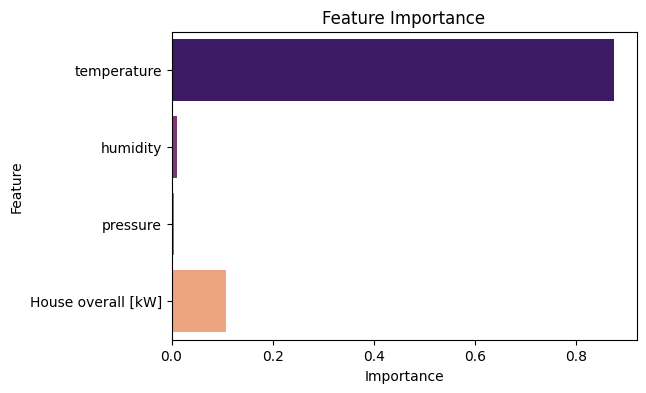

In [ ]:
#Feature Importance Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

importances = rf.feature_importances_
feature_names = X.columns

print("Feature Importance Values:")
print(list(zip(feature_names, importances)))

plt.figure(figsize=(6,4))
sns.barplot(x=importances, y=feature_names, palette='magma')
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


In [ ]:
import joblib

# Save the KNN model
joblib.dump(knn, 'smart_home_knn_model.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("KNN model saved successfully")
print("Label encoder saved successfully")

# Test prediction with the KNN model
test_sample = pd.DataFrame([[36.14, 0.62, 1016.91, 0.93]],
                            columns=['temperature', 'humidity',
                                     'pressure', 'House overall [kW]'])

prediction = knn.predict(test_sample)
print(f"Test prediction:")
print(f"Input: Temperature=36.14, Humidity=0.62, Pressure=1016.91, Energy=0.93")
print(f"Predicted class: {prediction[0]}")

KNN model saved successfully
Label encoder saved successfully
Test prediction:
Input: Temperature=36.14, Humidity=0.62, Pressure=1016.91, Energy=0.93
Predicted class: Normal


In [ ]:
# Export for Edge Impulse with numeric labels and timestamp
sample = df_iot.sample(n=5000, random_state=42).reset_index(drop=True)
sample_ei = sample[['temperature', 'humidity', 'pressure', 'House overall [kW]']].copy()

# Convert text labels to numbers
label_map = {'Normal': 0, 'Overheating': 1, 'High Energy': 2}
sample_ei['label'] = sample['label'].map(label_map)

# Add timestamp column
sample_ei.insert(0, 'timestamp', range(0, len(sample_ei) * 100, 100))

print(sample_ei.head())
print(sample_ei['label'].value_counts())

sample_ei.to_csv('edge_impulse_data.csv', index=False)

from google.colab import files
files.download('edge_impulse_data.csv')

   timestamp  temperature  humidity  pressure  House overall [kW]  label
0          0        52.95      0.86   1017.36            0.418867      0
1        100        36.01      0.92   1024.52            0.628783      0
2        200        68.74      0.53   1008.74            0.231417      0
3        300        46.12      0.37   1021.07            0.609450      0
4        400        12.53      0.49   1015.58            0.763600      0
label
0    4016
1     900
2      84
Name: count, dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Check exact column names first
print(df.columns.tolist())

['time', 'use [kW]', 'gen [kW]', 'House overall [kW]', 'Dishwasher [kW]', 'Furnace 1 [kW]', 'Furnace 2 [kW]', 'Home office [kW]', 'Fridge [kW]', 'Wine cellar [kW]', 'Garage door [kW]', 'Kitchen 12 [kW]', 'Kitchen 14 [kW]', 'Kitchen 38 [kW]', 'Barn [kW]', 'Well [kW]', 'Microwave [kW]', 'Living room [kW]', 'Solar [kW]', 'temperature', 'icon', 'humidity', 'visibility', 'summary', 'apparentTemperature', 'pressure', 'windSpeed', 'cloudCover', 'windBearing', 'precipIntensity', 'dewPoint', 'precipProbability']


Feature Importance Values:
  temperature: 0.8731 (87.3%)
  humidity: 0.0130 (1.3%)
  pressure: 0.0065 (0.7%)
  House overall [kW]: 0.1074 (10.7%)


/tmp/ipykernel_2490/2104736918.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=features, palette='magma')


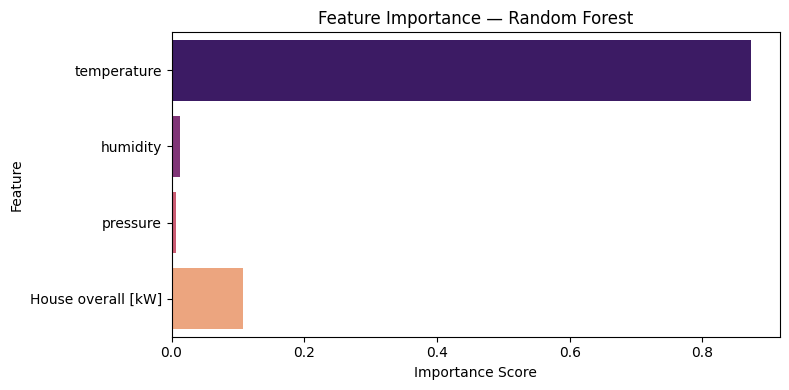

Saved!


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Train Random Forest for feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Get feature importance values
features = ['temperature', 'humidity', 'pressure', 'House overall [kW]']
importances = rf.feature_importances_

print("Feature Importance Values:")
for f, i in zip(features, importances):
    print(f"  {f}: {i:.4f} ({i*100:.1f}%)")

# Plot
plt.figure(figsize=(8, 4))
sns.barplot(x=importances, y=features, palette='magma')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")